<a href="https://colab.research.google.com/github/kenzoyanome/analisis_desconnecta/blob/main/Analisis_Desconnecta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Desconnecta
Evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamerica, *Desconnecta*.  
Trabajaremos con informacion registrada **hasta el año 2024**, lo cual permitira analizar el comportamiento del negocio dentro de ese periodo.

Trabajaremos con tres datasets:  
- **plans.csv** → informacion de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)
- **users.csv** → informacion de los clientes (edad, ciudad, fecha de registro, plan, churn)
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)

**Exploraremos**, **limpiaremos** y **analizaremos** estos datos para construir un **perfil estadistico** de los clientes, detectar **comportamientos atipicos** y crear **segmentos de clientes**.

Este analisis permitira **identificar patrones de consumo**, **diseñar estrategias de retencion** y **sugerir mejoras en los planes** ofrecidos por la empresa.  
<br>
<details>
<summary>Haz clic para ver cuantos puntos principales son:</summary>
Trabajaremos en 8 puntos distintos

---
## 1.0 Cargar y explorar
Antes de limpiar o combinar los datos, es necesario **familiarizarse con la estructura de los tres datasets**.  
En esta etapa, validaremos que los archivos se carguen correctamente, conoceremos sus columnas y tipos de datos, y detectaremos posibles inconsistencias.

---
### 1.1 Carga de datos y vista rapida
**Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerias necesarias
- Carga los archivos CSV:
  - `/plans.csv`
  - `/users_latam.csv`
  - `/usage.csv`
- Guarda los DataFrames en variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame

In [140]:
# importar librerías
import pandas            as pd
import numpy             as np
import seaborn           as sns
import matplotlib.pyplot as plt

# Otras configuraciones
import warnings                                                  #MANEJO DE WARNINGS - ADVERTENCIAS
warnings.simplefilter(action='ignore', category = FutureWarning) #QUITAR WARNINGS MOLESTOS
pd.set_option('display.max_columns', None)                       #ELIMINA LIMITES DE PANDAS PARA MOSTRAR COLUMNAS
pd.set_option('display.max_rows', None)                          #ELIMINA LIMITES DE PANDAS PARA MOSTRAR FILAS
pd.set_option('display.max_colwidth', None)                      #AUTOAJUSTA ANCHO DE COLUMNAS
pd.set_option('display.float_format', lambda x: '%.3f' % x)      #PERMITE EVADIR EL MOSTRAR NÚMEROS CON NOTACIÓN CINETÍFICA
plt.rcParams['figure.dpi'] = 140                                 #NIVEL DE RESOLUCIÓN.

In [141]:
# cargar archivos
plans = pd.read_csv('https://raw.githubusercontent.com/kenzoyanome/analisis_desconnecta/refs/heads/main/plans.csv')
users = pd.read_csv('https://raw.githubusercontent.com/kenzoyanome/analisis_desconnecta/refs/heads/main/users_latam.csv')
usage = pd.read_csv('https://raw.githubusercontent.com/kenzoyanome/analisis_desconnecta/refs/heads/main/usage.csv')

In [142]:
# mostrar las primeras filas de cada dataset
display(plans.head())
display(users.head())
display(usage.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.200,0.080,0.100
1,Premium,500,20,600,25,1.000,0.050,0.070


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.090,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.000
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.000
3,4,10682,call,2024-01-01 00:19:32.909322733,1.530,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.840,NaN


---
### 1.2 Exploracion de la estructura de los datasets
**Objetivo:**  
Conocer la estructura de cada dataset, revisar cuantas filas y columnas tienen, identificar los tipos de datos de cada columna y detectar posibles inconsistencias o valores nulos antes de iniciar el analisis.

**Instrucciones:**  
Revisa el numero de filas y columnas de cada dataset.  
Obtener un resumen completo de columnas, tipos de datos y valores no nulos.

In [143]:
# Conteo de filas y columnas
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [144]:
# Resumen completo de columnas, tipos de datos y valores no nulos
[plans.info(), users.info(), usage.info()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   ci

[None, None, None]

In [145]:
# Otra forma de mostrarlos seria:
import io
from IPython.display import display, HTML

def capture_info(df):
    buffer = io.StringIO()
    df.info(buf=buffer)
    return buffer.getvalue().replace("\n", "<br>")

html = f"""
<div style="display: flex; gap: 60px;">
  <div>{capture_info(plans)}</div>
  <div>{capture_info(users)}</div>
  <div>{capture_info(usage)}</div>
</div>
"""

display(HTML(html))

---
## 2.0 Identificación de problemas de calidad de datos
### 2.1 Revisión de valores nulos
**Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
Cuenta valores nulos por columna para cada dataset.
Calcula la proporción de nulos por columna para cada dataset.
El dataset plans solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

In [146]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id      0.000
first_name   0.000
last_name    0.000
age          0.000
city         0.117
reg_date     0.000
plan         0.000
churn_date   0.883
dtype: float64


In [147]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print(usage.isna().mean()) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id         0.000
user_id    0.000
type       0.000
date       0.001
duration   0.552
length     0.447
dtype: float64


**Comentarios y Notas:**  
¿Qué columnas tienen valores faltantes y en qué proporción?
- users: 'city' muestra un 11.7% de datos faltantes y 'churn_date' muestra un 88.4%
- usage: 'date' solo muestra 50 datos faltantes de los 40,000, 'duration' tiene 55.2% y 'length' un 44.7% the missings

Imputar, eliminar, ignorar?
- users - city: podriamos dejarlos como nulos a menos que tengamos que segmentar por 'city', entonces se recomendaria imputar datos o eliminar
- users - churn_date: debido a que esa columna nos ayuda a calcular la retencion, pudieramos dejarlos como nulos
- usage - date: ya que estamos trabajando solo en el periodo del 2024 y son pocos missings, pudieramos imputarlo
- usage - duration: podriamos dejarlos como nulos ya que estos solo muestran la duracion de llamadas en caso de existir
- usage - length: podriamos dejarlos como nulos ya que estos solo muestran la longituds de mensajes en caso de existir


---
### 2.2 Detección de valores invalidos y sentinels
**Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numericas con **un resumen estadistico**
- Explora las columnas categoricas **relevantes**, revisando sus valores unicos

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [148]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000,4000.000
mean,11999.500,33.740
std,1154.845,123.232
min,10000.000,-999.000
25%,10999.750,32.000
50%,11999.500,47.000
75%,12999.250,63.000
max,13999.000,79.000


**Comentarios y Notas:**  
- user_id: no existe discrepancia, los datos estan dentro de un mismo rango claro
- age: muestra minimos imposibles

In [149]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.000,40000.000,17924.000,22104.000
mean,20000.500,12002.406,5.202,52.127
std,11547.150,1157.280,6.843,56.611
min,1.000,10000.000,0.000,0.000
25%,10000.750,10996.000,1.438,37.000
50%,20000.500,12013.000,3.500,50.000
75%,30000.250,13005.000,6.990,64.000
max,40000.000,13999.000,120.000,1490.000


**Comentarios y Notas:**  
- id y user_id muestran valores correctos
- duration y legth muestran minimos en 0.0 (nulos) y valores maximos muy elevados

In [150]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
display(users[columnas_user].value_counts())
# explorar columna categórica de usage
usage['type'].value_counts()

,,count
city,plan,
Bogotá,Basico,522
CDMX,Basico,474
Medellín,Basico,398
GDL,Basico,298
Bogotá,Premium,286
MTY,Basico,275
Cali,Basico,262
CDMX,Premium,256
Medellín,Premium,218


,count
type,
text,22092
call,17908


**Comentarios y Notas:**  
En que columnas encontraste valores invalidos o sentinels?
- city: muestra valores invalidos dentro de ambos planes

Que accion tomarias?
- Pudieramos imputar con la ciudad mas frecuente de cada plan

---
### 2.3 Revision y estandarizacion de fechas
**Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el codigo sea a prueba de errores.
- Revisa cuantas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [151]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


,count
date,
2024.000,39950


**Comentarios y Notas:**  
reg_date: podemos observar que existen registros de usuarios en años distintos. Los años 2025 en adelante los sustituiremos por Na.   
date: las fechas aparecen del 2024 solamente, que es sobre las que trabajaremos.

---
## 3.0 Limpieza basica de datos
### 3.1 Corregir sentinels y fechas imposibles
**Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
Reemplaza sentinels (-999, ?).  
Marca como nulas las fechas fuera de rango.


In [152]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace((-999),age_mediana)
# Verificar cambios
users['age'].describe()

,age
count,4000.000
mean,48.122
std,17.690
min,18.000
25%,33.000
50%,47.000
75%,63.000
max,79.000


In [153]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace(("?"),pd.NA)
# Verificar cambios
print(users['city'].value_counts())
users['city'].isna().sum()

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64


np.int64(565)

In [154]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NA

# Verificar cambios
print(users['reg_date'].dt.year.value_counts())
users['reg_date'].isna().sum()

reg_date
2024.000    1330
2023.000    1316
2022.000    1314
Name: count, dtype: int64


np.int64(40)

---
### 3.2 Corregir sentinels y fechas imposibles
**Objetivo:**  
Decidir qué hacer con los valores nulos segun su proporcion y relevancia.

**Instrucciones:**  
Verifica los nulos en duration y length son **MCAR / MAR / MNAR**, revisando si dependen de la columna type.
- Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [155]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].agg(lambda x: x.isna().mean()).sort_values(ascending=False).head()

,duration
type,
text,0.999
call,0.000


In [156]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].agg(lambda x: x.isna().mean()).sort_values(ascending=False).head()

,length
type,
call,0.999
text,0.000


**Comentarios y Notas:**  
duration: Los nulos en duration dependen completamente de la variable type, por lo tanto NO son MAR  
legth: Los nulos en length también dependen completamente de type, por lo tanto: NO son MAR  
Los valores faltantes son estructurales (missing by design), ya que dependen directamente del tipo de interaccion. No corresponden a mecanismos MCAR, MAR o MNAR  
NO son errores, no deben imputarse ni eliminarse, son parte natural del diseño del dataset

duration falta cuando type = text  
length falta cuando type = call

---
## 4.0 Summary statistics de uso por usuario
### 4.1 Agrupacion por comportamiento de uso
**Objetivo:**  
Resumir las variables clave de la tabla `usage` **por usuario**, creando metricas que representen su comportamiento real de uso historico.

**Instrucciones:**
1. Construir una tabla agregada de `usage` por user_id que incluya:
- numero total de mensajes
- numero total de llamadas
- total de minutos de llamadas
2. Renombra las columnas para que tengan nombres claros:
- `cant_mensajes`
- `cant_llamadas`
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [157]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()
# Otra opcion de hacerlo seria:
#    usage_agg = usage.groupby('user_id').agg({
#        'is_text' : 'sum',                                   # Total de mensajes
#        'is_call' : 'sum',                                   # Total de llamadas
#        'duration': 'sum'                                    # Total de minutos de llamadas
#    }).reset_index()

# observar resultado
usage_agg.head()

,user_id,is_text,is_call,duration
0,10000,7,3,23.700
1,10001,5,10,33.180
2,10002,5,2,10.740
3,10003,11,3,8.990
4,10004,4,3,8.010


In [158]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.700
1,10001,5,10,33.180
2,10002,5,2,10.740


In [159]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='left')
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.000,3.000,23.700
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.000,10.000,33.180
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.000,2.000,10.740
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.000,3.000,8.990
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.000,3.000,8.010


In [160]:
# Verificar si hay usuarios sin datos de uso
user_profile[user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].isna().any(axis=1)]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
1082,11082,Luis,Gomez,39,CDMX,2022-10-24 06:31:03.465866468,Basico,NaN,NaN,NaN,NaN


### 4.2 4.2 Resumen estadistico por usuario durante el 2024

**Objetivo:**  
Analizar las columnas numericas y categoricas de los usuarios, para identificar rangos, valores extremos y distribucion de los datos antes de continuar con el analisis.

**Instrucciones:**  
1. Para las columnas **numericas** relevantes, obten un resumen estadistico (media, mediana, minimo, maximo, etc.).  
2. Para la columna **categorica** plan, revisa la distribucion en **porcentajes** de cada categoria.

In [161]:
# Resumen estadístico de las columnas numéricas
col_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[col_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000,3999.000,3999.000,3999.000
mean,48.122,5.524,4.478,23.317
std,17.690,2.358,2.144,18.168
min,18.000,0.000,0.000,0.000
25%,33.000,4.000,3.000,11.120
50%,47.000,5.000,4.000,19.780
75%,63.000,7.000,6.000,31.415
max,79.000,17.000,15.000,155.690


In [162]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).round(4)*100

,proportion
plan,
Basico,64.880
Premium,35.120


---
## 5.0 Visualizacion de distribuciones (uso y clientes) y outliers
### 5.1 Visualizacion de Distribuciones
**Objetivo:**  
Entender visualmente como se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias segun el tipo de plan, y analizar la **forma de la distribucion**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- age
- cant_mensajes
- cant_llamadas
- total_minutos_llamada

Despues de cada grafico, escribe un **insight** respecto al plan y la variable

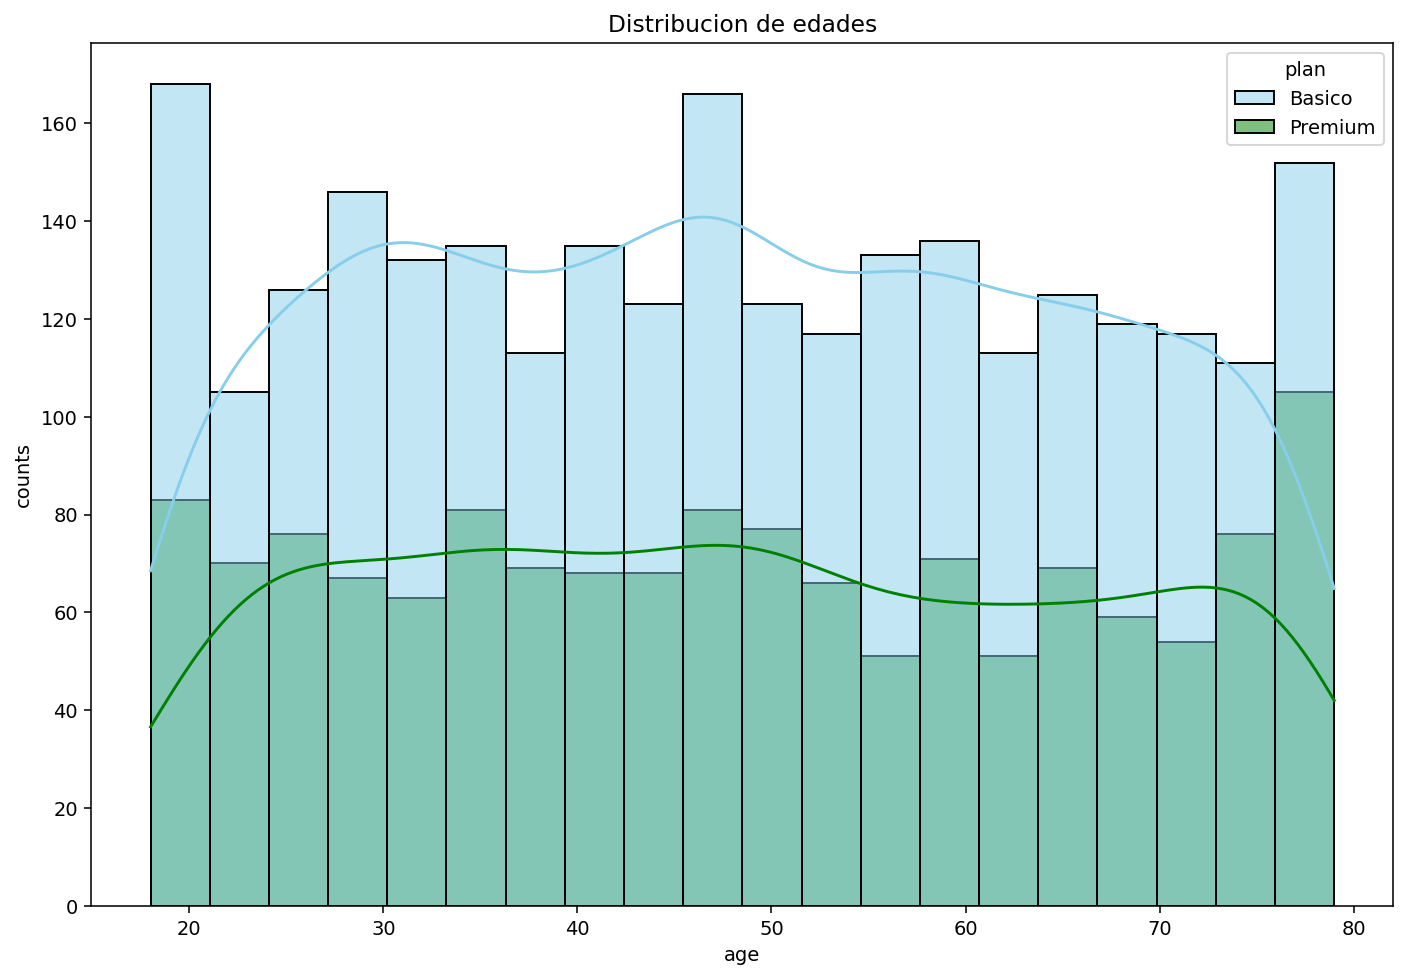

In [224]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(12,8))
sns.histplot(data=user_profile, x='age', bins=20, hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('age')
plt.ylabel('counts')
plt.title('Distribucion de edades')
#plt.legend(fontsize=100, bbox_to_anchor=(0.05,1), frameon=False, loc='upper left')
#plt.tight_layout()  # Ajusta automáticamente el layout
plt.show()

- Insights: No existe un rango dominante, los usuarios estan distribuidos (20-80)
- Distribucion casi uniforme

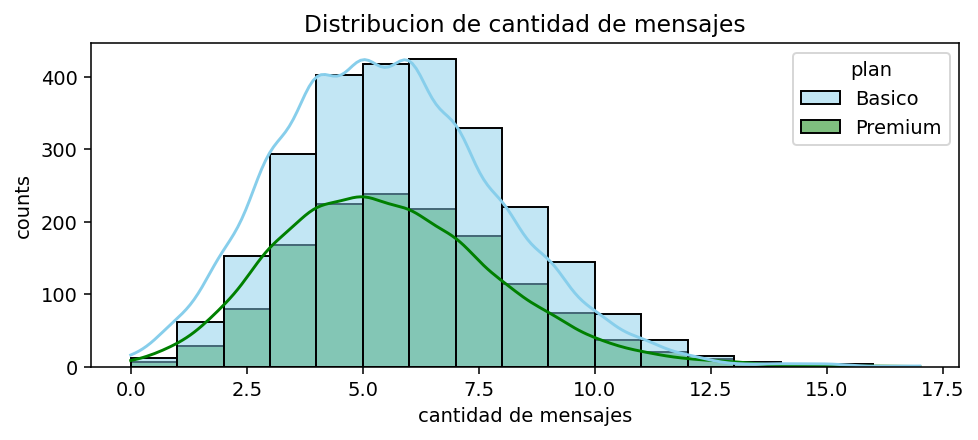

In [245]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,3))
sns.histplot(data=user_profile, x='cant_mensajes', bins=17, hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('cantidad de mensajes')
plt.ylabel('counts')
plt.title('Distribucion de cantidad de mensajes')
#plt.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.tight_layout()  # Ajusta automáticamente el layout
plt.show()

- Insights: el rango predominante es de 4 a 7 mensajes por usuario
- Existe un sesgo hacia la derecha (right-skewed)

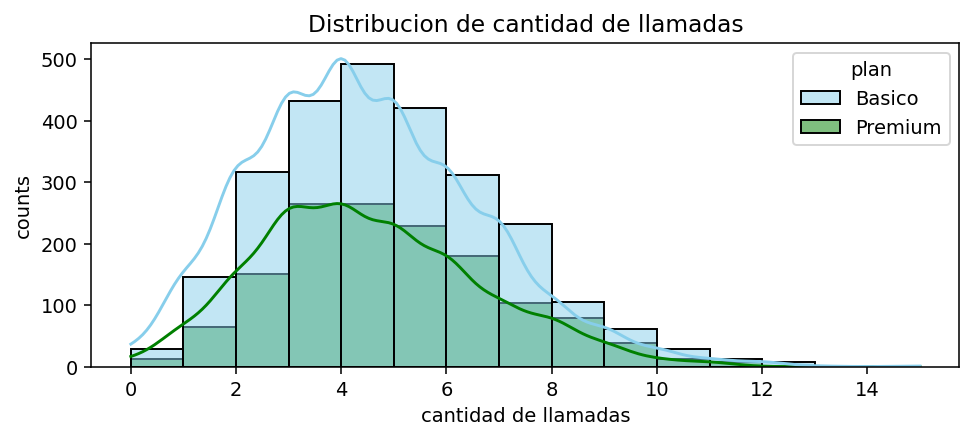

In [221]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,3))
sns.histplot(data=user_profile, x='cant_llamadas', bins=15, hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('cantidad de llamadas')
plt.ylabel('counts')
plt.title('Distribucion de cantidad de llamadas')
plt.show()

- Insights: el rango predominante es de 3 a 6 llamadas por usuario, nuestros "power users" donde pudieramos aplicar tecnicas de upselling y retencion
- Existe un sesgo hacia la derecha (right-skewed)

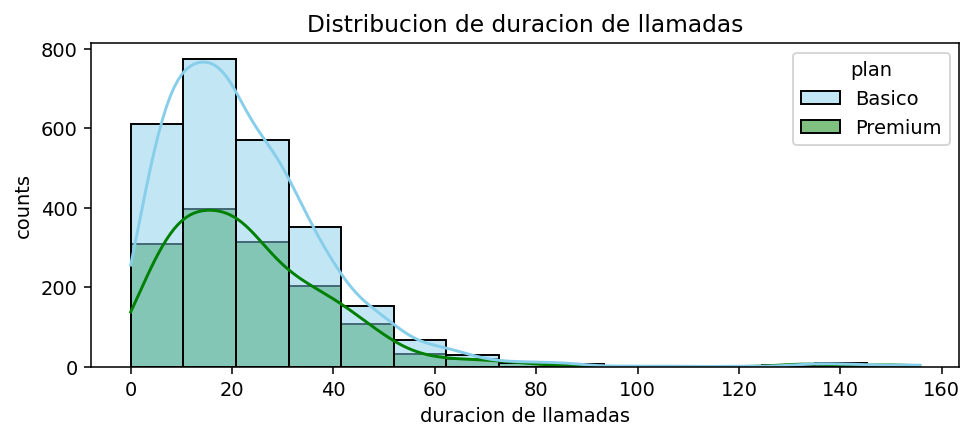

In [225]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,3))
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=15, hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('duracion de llamadas')
plt.ylabel('counts')
plt.title('Distribucion de duracion de llamadas')
plt.show()

- Insights: predominan las llamadas de una duracion de 10 a 20 minutos
- El sesgo se ve claramente marcado hacia la derecha

---
### 5.2 Identificacion de Outliers
**Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrian afectar el analisis, y decidir si requieren limpieza o revision adicional.

**Instrucciones:**
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:
  - age
  - cant_mensajes
  - cant_llamadas
  - total_minutos_llamada
- Crea un **for** para generar los 4 boxplots automaticamente.
- Despues de crear los grafico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los limites de esas columnas usando el **metodo IQR** y decide que hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos limites.

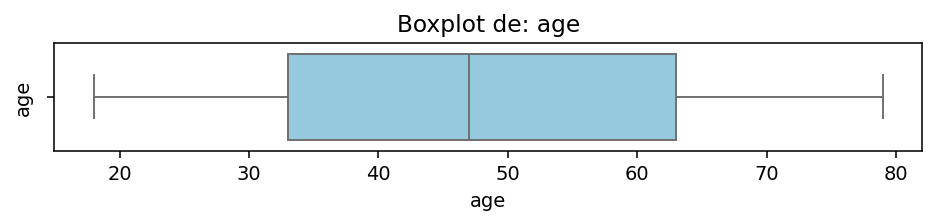

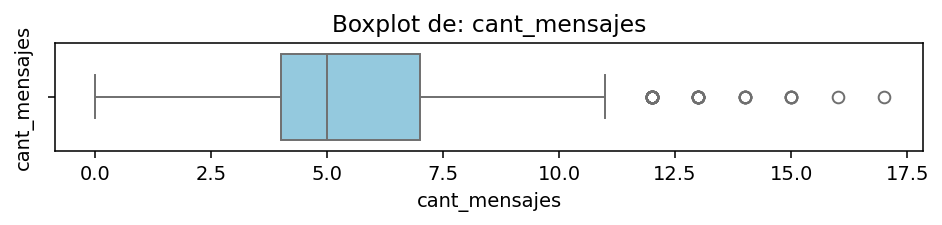

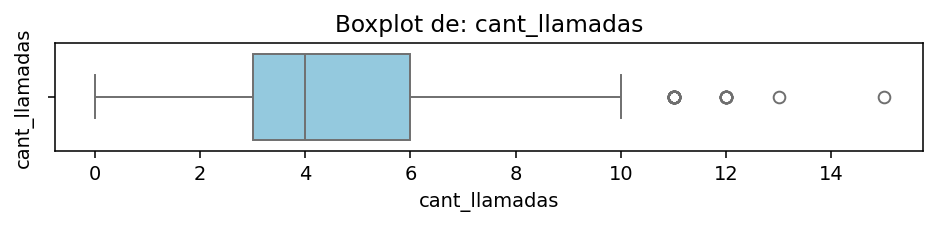

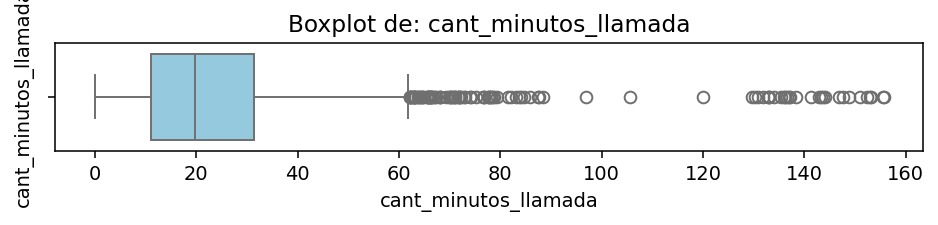

In [227]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8,1))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.ylabel(col)
    plt.title(f"Boxplot de: {col}")
    plt.show()

Insights:
- Age: muestra un rango fuerte entre los 33 y los 63 anos. Sin outliers significativos
- cant_mensajes: presenta outliers en la parte superior, hay un grupo de usuarios que envía una cantidad de mensajes considerablemente mayor que el promedio. Pocos "power users" de mensajeria.
- cant_llamadas: presenta outliers superiores, algunos usuarios realizan un número excepcionalmente alto de llamadas. La mayoría de los usuarios realizan un número moderado de llamadas, "power users" de llamadas reducidos.
- cant_minutos_llamada: presenta outliers superiores. Hay un subconjunto de usuarios con llamadas muy largas, lo que genera un fuerte sesgo a la derecha en la distribución.

In [246]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for cols in columnas_limites:
    Q1    = user_profile[cols].quantile(0.25)
    Q3    = user_profile[cols].quantile(0.75)
    IQR   = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    print(f"IQR de {cols}:")
    print(f"Q1:              {Q1:.2f}")
    print(f"Q3:              {Q3:.2f}")
    print(f"IQR:             {IQR:.2f}")
    print(f"limite superior: {upper:.2f}")
    print(f"limite inferior: {lower:.2f}")

    outliers = user_profile[user_profile[cols] > upper]

    print(f"Outliers en {cols} (>{upper:.2f}): {outliers.shape[0]} registros")
    display(outliers.head(3))
    print(f"Los datos son: {outliers[cols].sort_values(ascending=False).values}")
    print("-"*28)

IQR de cant_mensajes:
Q1:              4.00
Q3:              7.00
IQR:             3.00
limite superior: 11.50
limite inferior: -0.50
Outliers en cant_mensajes (>11.50): 46 registros


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
315,10315,Carlos,Lopez,30,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13.000,3.000,12.360,Alto uso,Adulto
347,10347,Carlos,Garcia,77,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13.000,3.000,21.400,Alto uso,Adulto Mayor
356,10356,Mateo,Garcia,42,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12.000,5.000,59.480,Alto uso,Adulto


Los datos son: [17. 16. 15. 15. 15. 15. 14. 14. 14. 14. 14. 13. 13. 13. 13. 13. 13. 13.
 13. 13. 13. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12.
 12. 12. 12. 12. 12. 12. 12. 12. 12. 12.]
----------------------------
IQR de cant_llamadas:
Q1:              3.00
Q3:              6.00
IQR:             3.00
limite superior: 10.50
limite inferior: -1.50
Outliers en cant_llamadas (>10.50): 30 registros


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
116,10116,Ana,Garcia,52,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3.000,11.000,44.320,Uso medio,Adulto
417,10417,Luis,Garcia,70,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4.000,12.000,26.420,Uso medio,Adulto Mayor
777,10777,Sofia,Lopez,65,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4.000,12.000,55.280,Uso medio,Adulto Mayor


Los datos son: [15. 13. 12. 12. 12. 12. 12. 12. 12. 12. 11. 11. 11. 11. 11. 11. 11. 11.
 11. 11. 11. 11. 11. 11. 11. 11. 11. 11. 11. 11.]
----------------------------
IQR de cant_minutos_llamada:
Q1:              11.12
Q3:              31.41
IQR:             20.30
limite superior: 61.86
limite inferior: -19.32
Outliers en cant_minutos_llamada (>61.86): 109 registros


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
27,10027,Ana,Gomez,28,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8.000,7.000,84.770,Uso medio,Joven
85,10085,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6.000,5.000,152.360,Uso medio,Adulto Mayor
93,10093,Ana,Torres,67,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2.000,7.000,71.570,Uso medio,Adulto Mayor


Los datos son: [155.69 155.42 153.06 153.02 152.36 150.92 148.76 147.53 146.92 143.97
 143.63 143.36 142.84 141.37 138.41 137.07 137.05 136.55 136.24 135.96
 135.36 133.97 133.1  132.92 132.72 131.88 130.84 130.23 129.75 120.
 105.54  96.88  88.45  87.56  87.38  85.8   84.77  84.1   83.72  83.06
  82.18  81.59  79.3   78.77  78.6   78.2   78.11  77.76  77.74  77.5
  76.76  76.69  76.65  75.28  74.14  74.05  73.    72.93  72.16  72.05
  71.9   71.76  71.57  71.09  71.02  70.8   70.58  70.29  70.21  70.12
  69.9   69.36  68.16  68.16  68.04  67.32  67.11  66.81  66.61  66.52
  66.2   66.08  66.04  66.04  65.84  65.79  65.71  65.56  65.55  64.77
  64.67  64.54  64.38  64.09  63.9   63.83  63.7   63.26  63.25  63.14
  63.05  63.05  62.99  62.78  62.42  62.35  62.16  62.12  62.11]
----------------------------


Insights:
- cant_mensajes: sugeriria mantener outliers ya que representan un comportamiento real.  
  No son valores extremos exagerados. Es totalmente normal que algunos usuarios manden más mensajes.
- cant_llamadas: mantener outliers, ayudaria a detectar heavy users y posibles estrategias de monetizacion.  
  No se muestran como errores.
- cant_minutos_llamada: investigar mas a fondo los outliers para saber si son usuarios de alto valor o casos raros (fraude, errores, bots).

---
## 6.0 Segmentacion de clientes
### 6.1 Segmentacion de clientes por uso
**Objetivo:**  
Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basandose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones logicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [247]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] <5) & (user_profile['cant_mensajes'] <5), 'Bajo uso', np.where(
        (user_profile['cant_mensajes'] <10) & (user_profile['cant_mensajes'] <10), 'Uso medio',
        'Alto uso' )
)

In [248]:
# verificar cambios
print(user_profile['grupo_uso'].value_counts())
user_profile.head()

grupo_uso
Uso medio    3009
Bajo uso      778
Alto uso      213
Name: count, dtype: int64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.000,3.000,23.700,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.000,10.000,33.180,Uso medio,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.000,2.000,10.740,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.000,3.000,8.990,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.000,3.000,8.010,Bajo uso,Adulto Mayor


### 6.2 Segmentacion de clientes por edad
**Objetivo:**  
Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usar comparaciones logicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [249]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] <30, 'Joven', np.where(
        user_profile['age'] <60, 'Adulto',
        'Adulto Mayor'
    )
)

In [250]:
# verificar cambios
user_profile.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
621,10621,Carlos,Gomez,32,GDL,2022-06-20 00:59:24.891222806,Premium,NaN,4.000,6.000,17.780,Uso medio,Adulto
2208,12208,Ana,Ramirez,50,MTY,2023-08-28 14:11:15.168792200,Basico,NaN,5.000,4.000,25.620,Uso medio,Adulto
280,10280,Carlos,Gomez,74,CDMX,2022-03-18 16:03:36.054013504,Premium,NaN,10.000,5.000,22.390,Alto uso,Adulto Mayor
1939,11939,Ana,Gomez,19,CDMX,2023-06-15 22:24:56.174043512,Basico,NaN,5.000,10.000,25.440,Uso medio,Joven
3914,13914,Luis,Gomez,21,Medellín,2024-12-07 17:24:37.269317328,Basico,NaN,3.000,9.000,31.350,Uso medio,Joven


---
### 6.3 Visualizacion de la segmentacion de clientes
**Objetivo:**  
Visualizar la distribucion de los usuarios segun los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**
- Crea dos graficos para las variables categoricas `grupo_uso` y `grupo_edad`.
- Agrega titulo y etiquetas a los ejes en cada grafico.

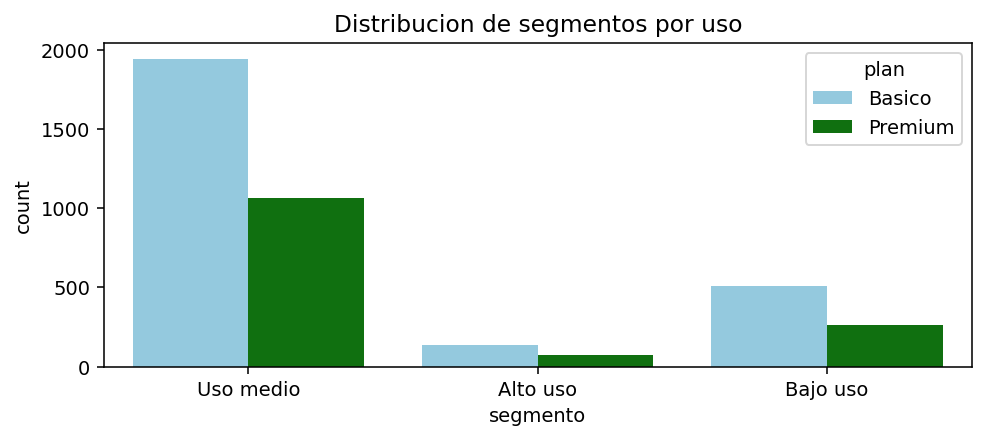

In [262]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,3))
sns.countplot(data=user_profile, x='grupo_uso', hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de segmentos por uso')
plt.xlabel('segmento')
plt.ylabel('count')
plt.show()

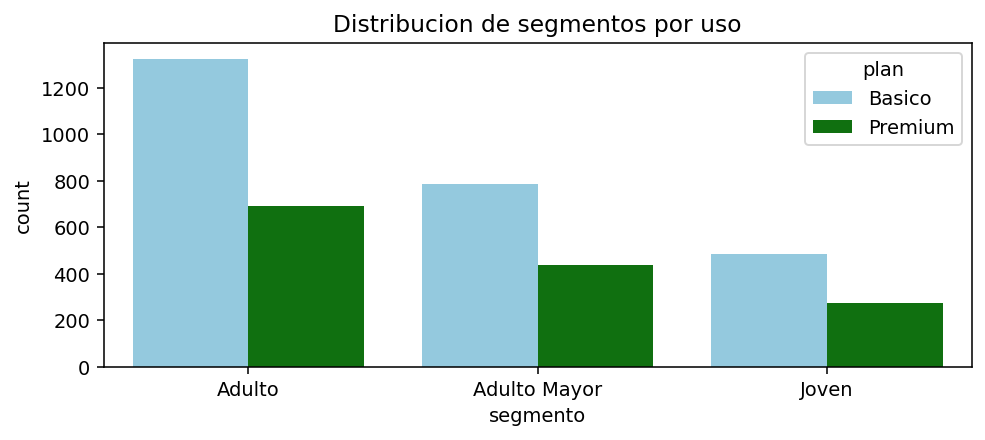

In [258]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,3))
sns.countplot(data=user_profile, x='grupo_edad', hue='plan', palette=['skyblue','green'])
plt.title('Distribucion de segmentos por uso')
plt.xlabel('segmento')
plt.ylabel('count')
plt.show()

---
## 7.0 Insight ejecutivo para Stakeholders
**Objetivo:**  
Traducir los hallazgos del analisis en conclusiones accionables para el negocio, enfocadas en segmentacion, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- Que problemas tenian originalmemte los datos?
- Que porcentaje, o cantidad de filas, de esa columna representaban?
- Que segmentos de clientes identificaste y como se comportan segun su edad y nivel de uso?
- Que segmentos parecen más valiosos para *Desconnecta* y por que?
- Que patrones de uso extremo (outliers) encontraste y que implican para el negocio?
- Que recomendaciones harias para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

### Análisis ejecutivo
⚠️ **Problemas detectados en los datos**
- Presencia de valores faltantes estructurales en variables de uso (duration, length), que dependen del tipo de interaccion y requieren tratamiento especifico.
- Existencia de outliers en variables de consumo (cant_llamadas, cant_minutos_llamada), los cuales no necesariamente son errores, sino posibles usuarios intensivos.
Valores no estandarizados en variables categoricas (ej: "?" en city), lo que puede afectar segmentaciones.
Distribucion de edad poco natural (cercana a uniforme), lo que podria indicar datos simulados o falta de sesgo realista.

🔍 **Segmentos por Edad**
- El segmento Adulto concentra la mayor parte de los usuarios en ambos planes, siendo el grupo dominante.
- El segmento Adulto Mayor tiene una presencia relevante, lo que sugiere que el producto no esta limitado a usuarios jovenes.
- El segmento Joven es el menos representado, indicando una posible oportunidad de crecimiento o menor adopcion en este grupo.
- La proporcion entre Basico vs Premium se mantiene relativamente estable entre edades, sin diferencias drasticas.

📊 **Segmentos por Nivel de Uso**
- El segmento de Uso medio domina claramente la base de usuarios en ambos planes.
- El segmento de Alto uso es el mas pequeño, lo que indica que los usuarios intensivos son minoria pero potencialmente valiosos.
- El segmento de Bajo uso, a pesar de no tener una presencia muy considerable, representa posibles usuarios en riesgo de churn.
- En todos los niveles de uso, el plan Basico tiene mayor volumen que Premium, lo que sugiere margen para estrategias de upselling.

➡️ **Esto sugiere**
- La base de usuarios es amplia pero mayormente concentrada en consumo medio, con pocos usuarios altamente intensivos.
- Existe una oportunidad clara de convertir usuarios de Uso medio y Bajo hacia planes Premium.
- Los usuarios de Bajo uso podrian representar un riesgo de abandono si no se activan adecuadamente.
- Los outliers identificados probablemente representan usuarios de alto valor mas que anomalias.

💡 **Recomendaciones**
- Diseñar estrategias de upselling dirigidas a usuarios de Uso medio, que ya muestran engagement.
- Implementar campañas de activacion para usuarios de Bajo uso para reducir churn.
- Analizar en profundidad a los usuarios de Alto consumo para entender patrones y replicarlos.
- Estandarizar y limpiar variables categoricas (ej: city) para mejorar la calidad del analisis.
Evaluar segmentaciones combinadas (edad + uso + plan) para identificar nichos de alto valor.